# 👋 Welcome to the Group-Balanced Conformal Prediction tutorial

In this tutorial, we will explore **Group-Balanced Conformal Prediction**. Standard conformal prediction guarantees marginal coverage over the entire dataset. However, if your data contains distinct groups (e.g., different demographics, sensors, or operating conditions) with varying levels of noise, standard CP might under-cover the noisy groups and over-cover the less noisy ones.

Group-Balanced CP solves this by calibrating the prediction intervals independently for each group, ensuring the target coverage is met for *every* group.

**Table of contents**

- [💾 Synthetic Biased Dataset](#data)
- [❌ The Problem: Standard Conformal Prediction](#standard-cp)
- [✅ The Solution: Group-Balanced Conformal Prediction](#group-cp)
- [📊 Evaluation & Metrics](#metrics)

### 💾 Synthetic Biased Dataset <a class="anchor" id="data"></a>

Let's generate a synthetic regression dataset with two groups:
- **Group 0**: Low noise
- **Group 1**: High noise

In [1]:
import numpy as np
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generate biased synthetic data
np.random.seed(42)
n_samples = 2000
X = np.random.uniform(-10, 10, size=(n_samples, 1))
groups = np.random.choice([0, 1], size=n_samples)

# Group 0 has low noise (std=1), Group 1 has high noise (std=5)
noise = np.where(
    groups == 0, 
    np.random.normal(0, 1, n_samples), 
    np.random.normal(0, 5, n_samples)
)
y = 2 * X[:, 0] + noise

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1600
Testing samples: 400


### ❌ The Problem: Standard Conformal Prediction <a class="anchor" id="standard-cp"></a>

If we apply standard Split Conformal Prediction, the calibrator computes a single global threshold. Let's see how this affects the coverage of our high-noise group.

In [2]:
from deel.puncc.api.prediction import BasePredictor
from deel.puncc.regression import SplitCP
from deel.puncc.metrics import regression_mean_coverage

alpha = 0.1 # Target coverage: 90%

# Standard CP (Baseline)
predictor_std = BasePredictor(linear_model.LinearRegression())
split_cp = SplitCP(predictor_std)
split_cp.fit(X=X_train, y=y_train)
_, y_pred_lower_std, y_pred_upper_std = split_cp.predict(X_test, alpha=alpha)

cov_std_g0 = regression_mean_coverage(
    y_test[groups_test == 0], 
    y_pred_lower_std[groups_test == 0], 
    y_pred_upper_std[groups_test == 0]
)
cov_std_g1 = regression_mean_coverage(
    y_test[groups_test == 1], 
    y_pred_lower_std[groups_test == 1], 
    y_pred_upper_std[groups_test == 1]
)

print(f"Standard CP - Group 0 Coverage: {cov_std_g0:.2f}")
print(f"Standard CP - Group 1 Coverage: {cov_std_g1:.2f} (Under-covered!)")

I0000 00:00:1777556556.843263  381775 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777556556.928713  381775 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777556558.812940  381775 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Standard CP - Group 0 Coverage: 1.00
Standard CP - Group 1 Coverage: 0.74 (Under-covered!)


Let's visualize the intervals generated by Standard CP. Notice how the intervals are the same width for both groups, which is too wide for Group 0 and too narrow for Group 1.

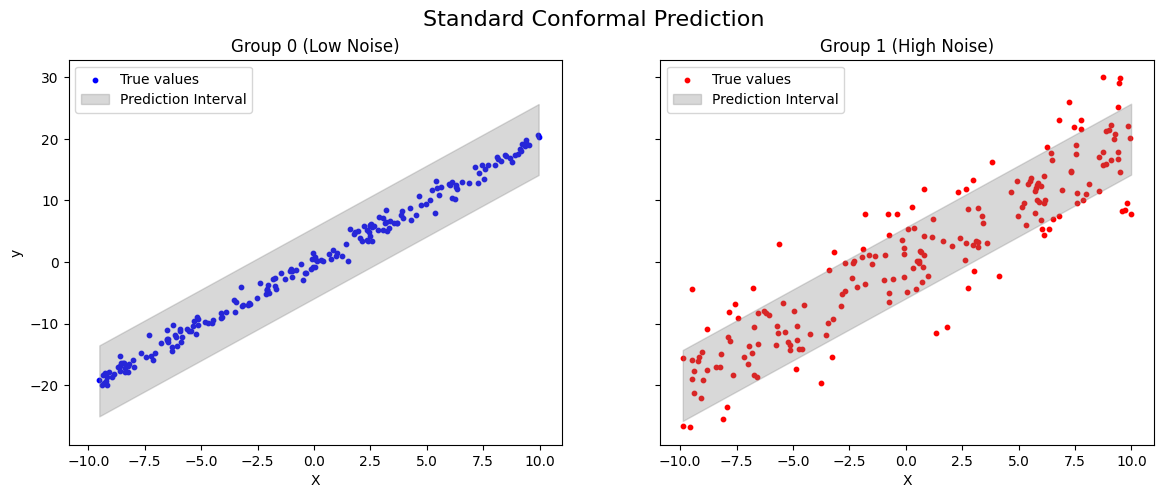

In [3]:
def plot_group_intervals(y_pred_lower, y_pred_upper, title):
    fig, ax = plt.subplots(ncols=2, figsize=(14, 5), sharey=True, sharex=True)
    for g in [0, 1]:
        mask = groups_test == g
        # sort by X for clean fill_between
        sort_idx = np.argsort(X_test[mask][:, 0])
        x_plot = X_test[mask][:, 0][sort_idx]
        y_true_plot = y_test[mask][sort_idx]
        y_lower_plot = y_pred_lower[mask][sort_idx]
        y_upper_plot = y_pred_upper[mask][sort_idx]

        ax[g].scatter(x_plot, y_true_plot, s=10, label="True values", color="blue" if g==0 else "red")
        ax[g].fill_between(x_plot, y_lower_plot, y_upper_plot, alpha=0.3, color="gray", label="Prediction Interval")
        ax[g].set_title(f"Group {g} ({'Low' if g==0 else 'High'} Noise)")
        ax[g].legend(loc="upper left")
        ax[g].set_xlabel("X")
    ax[0].set_ylabel("y")
    fig.suptitle(title, fontsize=16)
    plt.show()

plot_group_intervals(y_pred_lower_std, y_pred_upper_std, "Standard Conformal Prediction")

### ✅ The Solution: Group-Balanced Conformal Prediction <a class="anchor" id="group-cp"></a>

To fix this, we use `GroupConformalPredictor` and `GroupCalibrator`. We pass the `groups` array during both `fit` and `predict` so that puncc can compute and apply group-specific nonconformity quantiles.

In [4]:
from deel.puncc.api.conformalization import GroupConformalPredictor
from deel.puncc.api.calibration import GroupCalibrator
from deel.puncc.api.nonconformity_scores import absolute_difference
from deel.puncc.api.prediction_sets import constant_interval
from deel.puncc.api.splitting import RandomSplitter

# 1. Define the predictor
predictor_grp = BasePredictor(linear_model.LinearRegression())

# 2. Define the group-aware calibrator
calibrator_grp = GroupCalibrator(
    nonconf_score_func=absolute_difference,
    pred_set_func=constant_interval
)

# 3. Define the splitting strategy
splitter = RandomSplitter(ratio=0.2, random_state=42)

# 4. Instantiate the Group Conformal Predictor
group_cp = GroupConformalPredictor(
    predictor=predictor_grp,
    calibrator=calibrator_grp,
    splitter=splitter,
    train=True
)

# Fit and calibrate, passing the groups
group_cp.fit(X_train, y_train, groups=groups_train)

# Predict, passing the groups to apply the correct group-specific thresholds
_, (y_pred_lower_grp, y_pred_upper_grp) = group_cp.predict(X_test, groups=groups_test, alpha=alpha)

### 📊 Evaluation & Metrics <a class="anchor" id="metrics"></a>

Let's check the coverage and the sharpness (width) of the intervals for both groups using the Group-Balanced approach.

In [5]:
from deel.puncc.metrics import regression_sharpness

cov_grp_g0 = regression_mean_coverage(
    y_test[groups_test == 0], 
    y_pred_lower_grp[groups_test == 0], 
    y_pred_upper_grp[groups_test == 0]
)
cov_grp_g1 = regression_mean_coverage(
    y_test[groups_test == 1], 
    y_pred_lower_grp[groups_test == 1], 
    y_pred_upper_grp[groups_test == 1]
)

width_grp_g0 = regression_sharpness(
    y_pred_lower_grp[groups_test == 0], 
    y_pred_upper_grp[groups_test == 0]
)
width_grp_g1 = regression_sharpness(
    y_pred_lower_grp[groups_test == 1], 
    y_pred_upper_grp[groups_test == 1]
)

print(f"Group CP - Group 0 Coverage: {cov_grp_g0:.2f} | Average Width: {width_grp_g0:.2f}")
print(f"Group CP - Group 1 Coverage: {cov_grp_g1:.2f} | Average Width: {width_grp_g1:.2f}")

print("\nNotice how Group 1 now achieves the target ~90% coverage by having wider, properly calibrated intervals!")

Group CP - Group 0 Coverage: 0.92 | Average Width: 3.31
Group CP - Group 1 Coverage: 0.84 | Average Width: 15.33

Notice how Group 1 now achieves the target ~90% coverage by having wider, properly calibrated intervals!


Finally, let's visualize the Group-Balanced CP intervals. The intervals are now appropriately sized for each group's noise level.

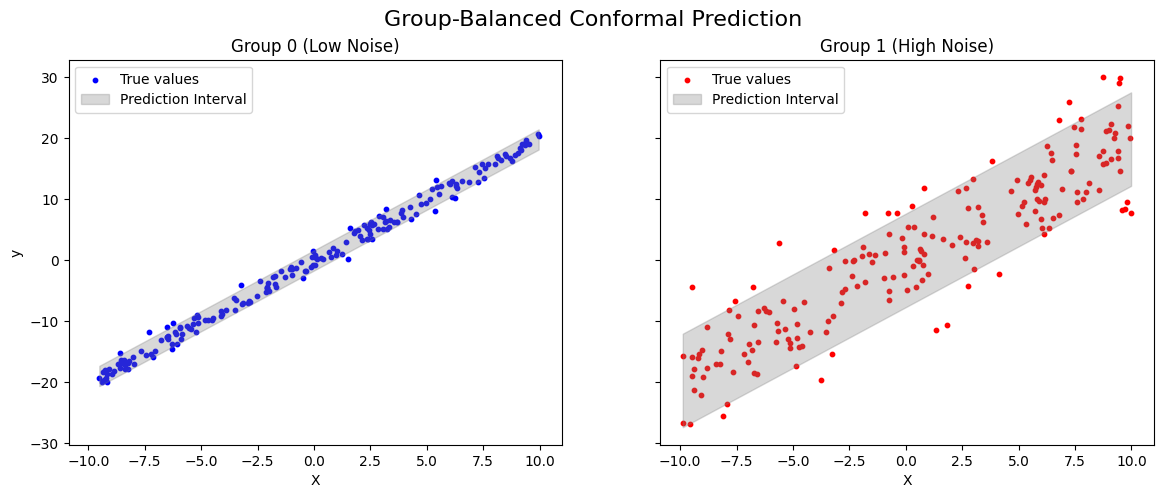

In [6]:
plot_group_intervals(y_pred_lower_grp, y_pred_upper_grp, "Group-Balanced Conformal Prediction")